In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq


# Setup pytrend library and keyword define

In [2]:
pytrends = TrendReq(hl = 'en-US', tz = 360)
keyword = "cloud computing"

# Data Request

In [4]:
pytrends.build_payload([keyword], cat = 0, timeframe= 'today 12-m', geo='', gprop= '')

In [5]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending= False).head(15)


C:\Users\jeeva\AppData\Local\Temp\ipykernel_42952\2278157171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


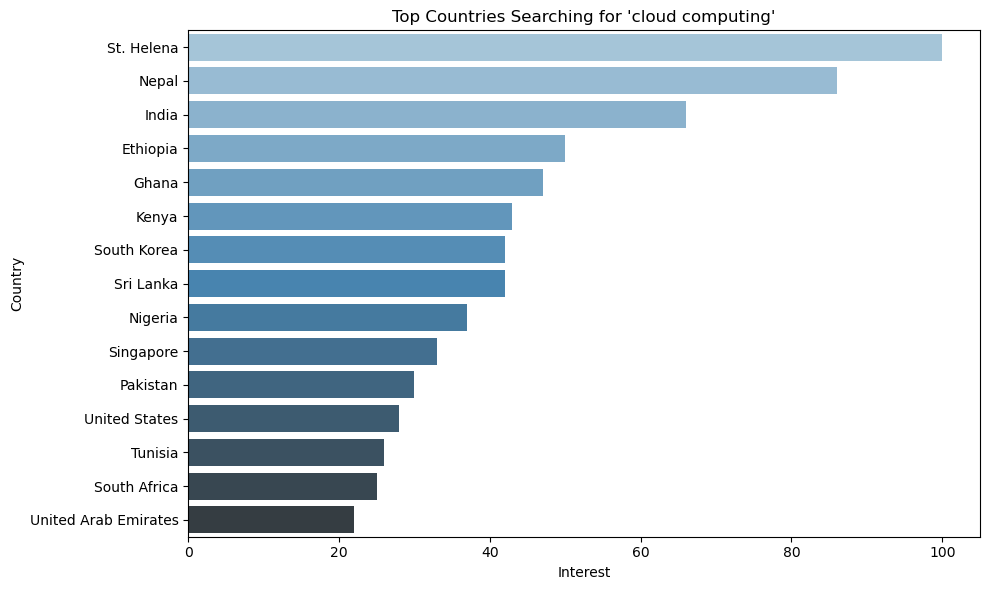

In [6]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_data[keyword],
    y=region_data.index,
    palette="Blues_d",
    orient="h"
)

plt.title(f"Top Countries Searching for '{keyword}'")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# World map

In [7]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations = 'geoName',
                    locationmode = 'country names',
                    color = keyword,
                    title = f"Search Interest for '{keyword}' by Country",
                    color_continuous_scale = 'Blues')

C:\Users\jeeva\AppData\Local\Temp\ipykernel_42952\153307305.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(region_data,


# Time wise interest

In [8]:
time_df = pytrends.interest_over_time()

C:\Users\jeeva\anaconda3\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



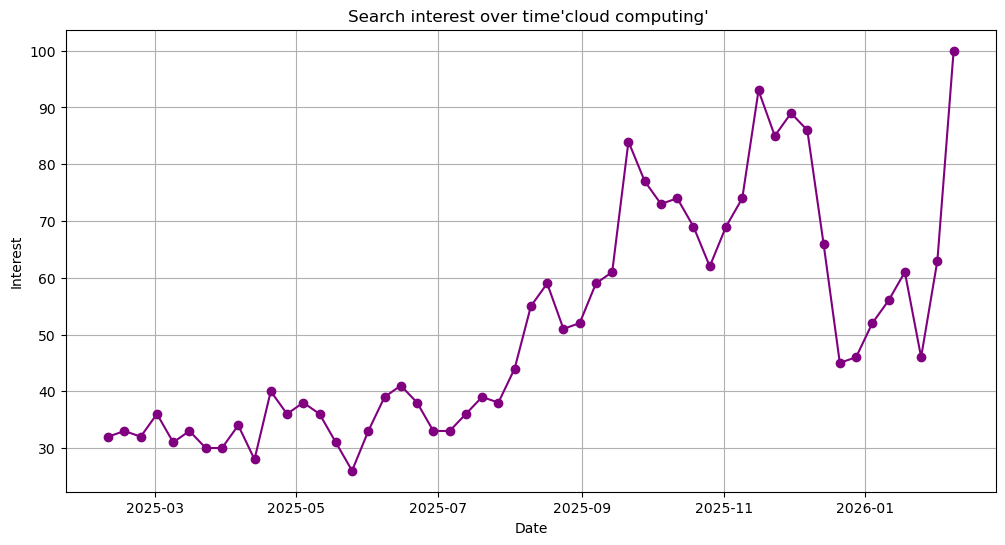

In [9]:
plt.figure(figsize=(12,6))
plt.plot(time_df.index, time_df[keyword], marker = 'o', color ='purple')
plt.title(f"Search interest over time'{keyword}' ")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()
          

# Multiple keywords compare

In [13]:
kw_list = ["cloud computing", "data science", "machine learning"]
pytrends.build_payload(kw_list, cat = 0, timeframe= 'today 12 -m', geo= '', gprop='')

ResponseError: The request failed: Google returned a response with code 400

C:\Users\jeeva\anaconda3\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



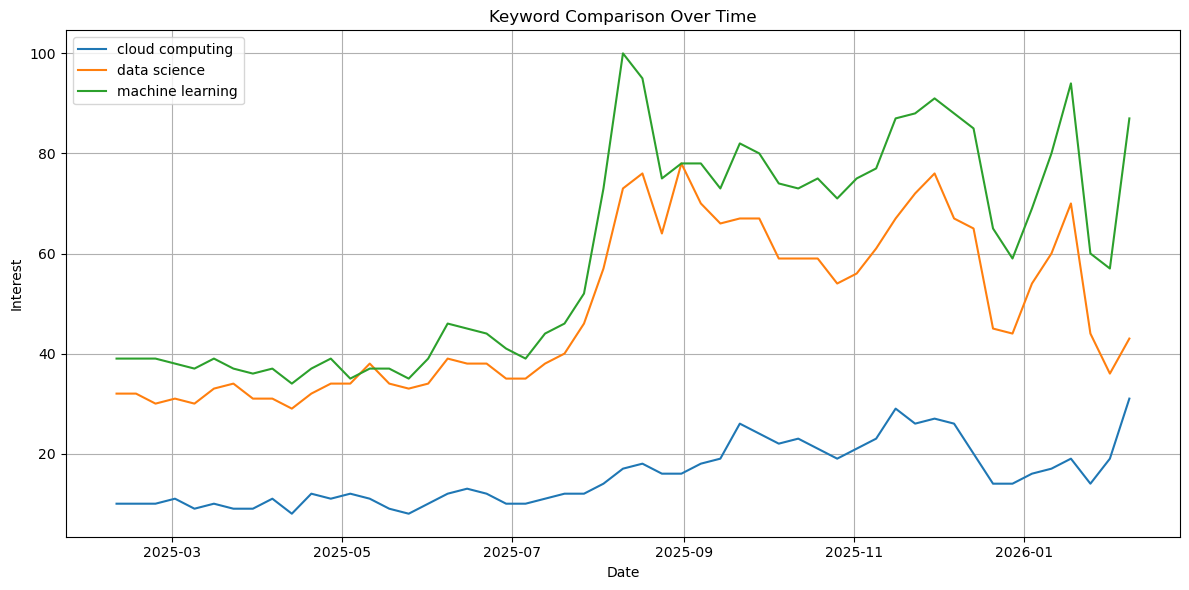

In [12]:
# Build payload first
pytrends.build_payload(
    kw_list=kw_list,
    timeframe='today 12-m'
)

# Get data
compare_df = pytrends.interest_over_time()

# Drop isPartial column if present
if 'isPartial' in compare_df.columns:
    compare_df = compare_df.drop(columns=['isPartial'])

# Plot
plt.figure(figsize=(12, 6))

for kw in kw_list:
    if kw in compare_df.columns:
        plt.plot(compare_df.index, compare_df[kw], label=kw)

plt.title("Keyword Comparison Over Time")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
